# 103.7. How to create a large cutout from deep_coadd images

<div style="max-width:300px; float: left; margin-right: 1em">

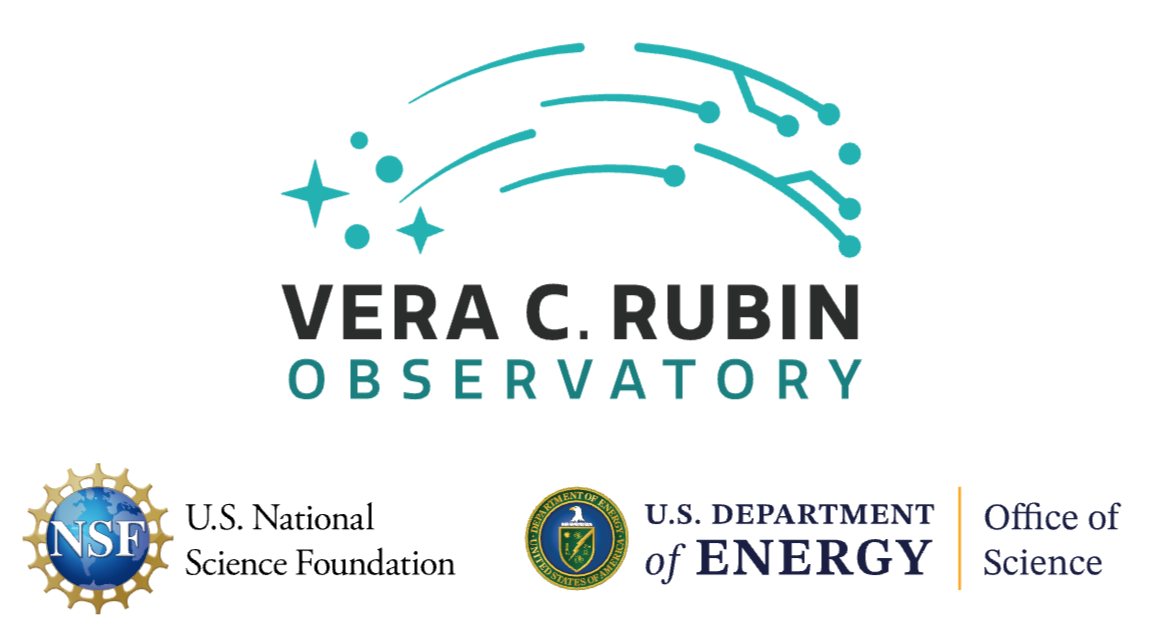

</div>

For the Rubin Science Platform at data.lsst.cloud. <br>
Data Release: <a href="https://dp1.lsst.io">Data Preview 1</a> <br>
Container Size: large <br>
LSST Science Pipelines version: r29.2.0 <br>
Last verified to run: 2025-09-11 <br>
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a> <br>

**Learning objective:** Create a large custom `deep_coadd` cutout.

**LSST data products:** `deep_coadd`.

**Packages:** `lsst.daf.butler`, `lsst.ip.diffim.GetTemplateTask`.

**Credit:** Originally developed by Andrés A. Plazas Malagón and the Rubin Community Science team with input from Nate Lust.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the 
<a href="https://community.lsst.org/c/support">Support Category</a> 
of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction




**Related tutorials**: 

### 1.1. Import packages

Import the `Butler` module from the `lsst.daf.butler` package, and the `display` module from the `lsst.afw` package (for image display).

In [3]:
import numpy as np
from lsst.daf.butler import Butler
import lsst.afw.display as afwDisplay

from lsst.daf.butler import Butler

from lsst.geom import Box2I, Point2I, Extent2I, SpherePoint, degrees
from lsst.sphgeom import Box as SphBox

from lsst.pipe.tasks.prettyPictureMaker import PrettyPictureTask
from lsst.pipe.tasks.prettyPictureMaker._task import ChannelRGBConfig
from lsst.ip.diffim import GetTemplateTask
from lsst.pipe.tasks.makeDiscreteSkyMap import MakeDiscreteSkyMapTask

import matplotlib.pyplot as plt

### 1.2. Define parameters and functions

In [4]:
def coord_list_to_tract_patch(coord_list, skymap):
    """Create a list of tract, patch pairs for each coordinate in the input list.

    Parameters
    ----------
    coord_list : `list` of `lsst.geom.SpherePoint`
        List of coordinates for which the closest tract, patch region is to be
        found.
    skymap : `lsst.skymap.BaseSkymap`
        The skymap from where the tract, patch pairs are to be determined.

    Results
    -------
    results : `list` of `tuple` of `int`, `int`
        A list the same length as the input which each element is the closest
        tract patch to the corresponding coordinate. A tuple of -1, -1 will
        be returned if a coordinate can't be attributed to a tract, patch.

    Notes
    ----
    The patch number returned is the sequential index used to identify patches
    in the butler.
    """
    results = []
    for coord in coord_list:
        tractInfo = skymap.findTract(coord)
        for patchInfo in tractInfo:
            if patchInfo.getInnerSkyPolygon().contains(coord.getVector()):
                results.append((tractInfo.getId(), patchInfo.getSequentialIndex()))
                break
        else:
            results.append((-1, -1))
    return results

Instantiate the butler.

In [5]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
assert butler is not None

Define the skymap.

In [6]:
skymap = butler.get("skyMap")

## 2. Prepare to create the cutout

Use the galaxy cluster Abell 360 (A360), a rich galaxy cluster at redshift 0.22 that is included in the DP1 data release in the `RV_ ` field.

Define the coordinates of the brightest cluster galaxy (BCG), in degrees.

In [7]:
ra_bcg = 37.865
dec_bcg = 6.98

Define a box size of 0.1 degrees around the BCG, then search for all patches within twice that size (2 * `box_size_deg`).

In [9]:
box_size_deg = 0.1

Define the region from where the `deep_coadd` dataset references will be retrieved.

In [34]:
box_region = SphBox.fromDegrees(ra_bcg - box_size_deg, dec_bcg - box_size_deg,
                                ra_bcg + box_size_deg, dec_bcg + box_size_deg)

Get the dataset references in the `r` band.

In [35]:
bands = "('r')"

In [25]:
dataset_refs = set(
    butler.query_datasets(
        "deep_coadd",
        where=f"patch.region OVERLAPS(region) and band in {bands}",
        bind={"region": box_region}
    )
)

Inspect the references for the `deep_coadd`s, corresponding to different patches in the region.

In [22]:
dataset_refs

{DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, ExposureF), {band: 'r', skymap: 'lsst_cells_v1', tract: 10463, patch: 61}, run='LSSTComCam/runs/DRP/DP1/DM-51335', id=8aa7f95c-3dbe-476c-85c8-4e2281149c62),
 DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, ExposureF), {band: 'r', skymap: 'lsst_cells_v1', tract: 10463, patch: 62}, run='LSSTComCam/runs/DRP/DP1/DM-51335', id=c85e7244-2e5a-4243-97b1-003967101a74),
 DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, ExposureF), {band: 'r', skymap: 'lsst_cells_v1', tract: 10463, patch: 71}, run='LSSTComCam/runs/DRP/DP1/DM-51335', id=0e665dab-7ad3-4541-a79b-8fb57cc5d145),
 DatasetRef(DatasetType('deep_coadd', {band, skymap, tract, patch}, ExposureF), {band: 'r', skymap: 'lsst_cells_v1', tract: 10463, patch: 72}, run='LSSTComCam/runs/DRP/DP1/DM-51335', id=61911c12-3d76-497b-8312-d07c3c9360b4)}

Prepare the inputs for building a custom skymap. For each dataset reference, the WCS and bounding box of its patch are stored, so the collection of positions can later define a skymap that includes only the data in use. At the same time, the dataset references are organized into a nested dictionary: first grouped by band, then within each band grouped by tract. Each tract key contains all the dataset refs for that tract band combination.

In [26]:
position_container = []
sorted_data = {}
for ds_ref in dataset_refs:
    did = ds_ref.dataId

    patchInfo = skymap[did["tract"]][did["patch"]]
    position_container.append((patchInfo.wcs, patchInfo.outer_bbox))

    band_container = sorted_data.setdefault(did["band"], dict())
    tract_container = band_container.setdefault(did["tract"], list())
    tract_container.append(ds_ref)

## 3. Create the cutout

Create an image of an arbitrary sky region that is not aligned with the native Legacy Survey of Space and Time (LSST) sky tessellation.
This is similar to the process in alert production, where past LSST observations are combined to generate static-sky templates for detecting transients in new exposures.
The same template-generation code (`getTemplateTask`) can be used to transform input data aligned on the LSST tessellation into the required geometry.

To use the template code, a single astrometric solution or World Coordinate System (WCS) that encompasses all input data is needed, instead of having a separate tangent-plane WCS for each tract.
A discrete skymap is therefore created for the input data, producing one tract with a single WCS projection.
A bounding box is then defined in these new coordinates, centered on the brightest cluster galaxy (BCG) and spanning the specified width.

With this setup, images are generated per band by combining the inputs that fall within the bounding box. The `GetTemplateTask` creates coadds for each band.

Make a skymap that contains all input data.

In [27]:
new_skymap = MakeDiscreteSkyMapTask().run(position_container).skyMap

Get the new WCS from the single tract discrete skymap.

In [28]:
new_wcs = new_skymap[0].wcs

In [42]:
new_wcs

FITS standard SkyWcs:
Sky Origin: (37.8481271152, +7.0272990684)
Pixel Origin: (3999, 3999)
Pixel Scale: 0.333 arcsec/pixel

Create a bounding box in the new WCS coordinates that is centered on the BCG and has the width defined above.

In [38]:
small_box = Box2I(
    Point2I(new_wcs.skyToPixel(SpherePoint(ra_bcg - box_size_deg,
                                           dec_bcg - box_size_deg, degrees))),
    Point2I(new_wcs.skyToPixel(SpherePoint(ra_bcg + box_size_deg,
                                           dec_bcg + box_size_deg, degrees))),
)

Loop over bands (just the `r` band in this case) to create images that are combinations of the inputs contained within the defined box. Note that the run method modifies the bounding box in place, so a copy is made.

In [72]:
getTemplateTask = GetTemplateTask()
coadds = {}
for band, mapping in sorted_data.items():
    small_box_copy = Box2I(small_box)
    new_image = getTemplateTask.run(
        coaddExposures={
            tract: [butler.get(ref) for ref in refs] for tract, refs in mapping.items()
        },
        bbox=small_box_copy,
        wcs=new_wcs,
        dataIds={tract: [ref.dataId for ref in refs] for tract, refs in mapping.items()},
        physical_filter=band,
    )#.template
    coadds[band] = new_image

Point2I(2725, 2387)

## 4. Visualize the custom cutout

Extract metadata for the custom cutout.

In [73]:
newimage_wcs_fmd = coadds['r'].template.getWcs().getFitsMetadata()

In [75]:
newimage_extent = (small_box_copy.beginX, small_box_copy.endX,
                   small_box_copy.beginY, small_box_copy.endY)

In [76]:
new_wcs

FITS standard SkyWcs:
Sky Origin: (37.8481271152, +7.0272990684)
Pixel Origin: (3999, 3999)
Pixel Scale: 0.333 arcsec/pixel

In [77]:
from astropy.wcs import WCS

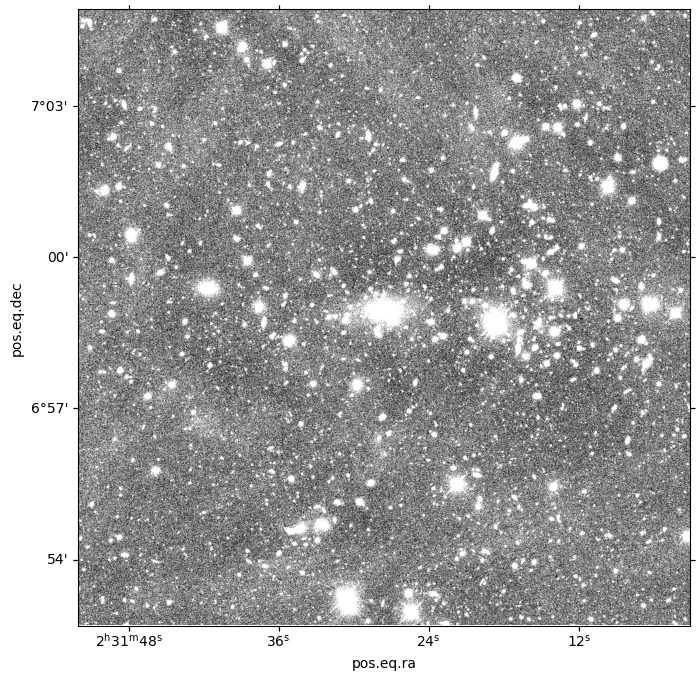

In [80]:
fig = plt.figure(figsize=(8, 8))
plt.subplot(projection=WCS(newimage_wcs_fmd))
plt.imshow(coadds['r'].template.image.array, vmin=0.01, vmax=0.5,
           extent=newimage_extent, origin='lower', cmap='gray')

#aperture = SkyCircularAperture(coord, r=radius)
#pix_aperture = aperture.to_pixel(WCS(newimage_wcs_fmd))
#pix_aperture.plot(color='r', lw=3)

plt.show()

In [81]:
afwDisplay.setDefaultBackend('matplotlib')

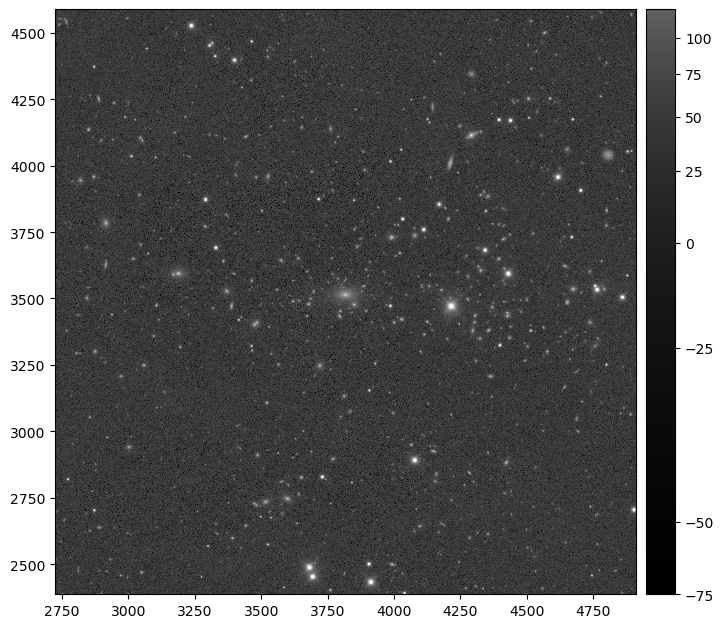

In [82]:
fig = plt.figure(figsize=(8, 8))
display = afwDisplay.Display(frame=fig)
display.scale('asinh', 'zscale')
display.mtv(coadds['r'].template.image)
plt.show()

### 4.3. Display with Firefly

Firefly allows for interactive image display and manipulation.
See DP0.2 tutorial notebook 03b for a full demonstration of how to use Firefly within the Notebook Aspect.

Reset the `afwDisplay` backend to be Firefly and start the display.
A new tab will open, containing the Firefly interface.

In [86]:
afwDisplay.setDefaultBackend('firefly')
afw_display = afwDisplay.Display(frame=1)

In [87]:
afw_display.mtv(coadds['r'].template)

In [88]:
afw_display.setMaskTransparency(100)